# Node 1: Claims Anomaly Trigger Engine

**Hackathon Proof of Concept**
**Component 1 of 2: the statistical trigger engine behind the Cotiviti Agentic Audit Copilot**

This full code implements the statistical detection layer described in the
written report's Human-in-the-Loop (HITL) Adjudication Layer: a
rolling-statistics engine that scans claims for aberrant utilization
behavior (pre-pay DRG upcoding, operational spikes, and other deviations
from a provider's normal billing pattern) and surfaces them for downstream
investigation. It mirrors the logic in the interactive HTML demo
(`Claims_Anomaly_Detector_POC.html`), implemented here in pandas/numpy.

**Architecture:** This is Node 1 — the Trigger Engine. 
It does not investigate *why* a claim is anomalous or produce a
narrative explanation; it only decides *which* claims are statistically
worth investigating, and at what confidence. Claims that cross the
threshold here are handed off to Node 2 (`Agentic_Claims_Investigator.ipynb`
— the Generative AI Clinical Reasoner) for evidence-backed narrative
investigation and a human-reviewable recommendation.

**Method:** for each provider's claim sequence, compute a trailing rolling
mean and standard deviation. Any claim whose billed amount deviates from
that rolling mean by more than a chosen z-score threshold is flagged as a
potential anomaly, with the z-score itself serving as a plain, auditable
"reason code" rather than a black-box decision.


## 1. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


Matplotlib is building the font cache; this may take a moment.


## 2. Generate synthetic claims data

Real claims history would come from a payment-integrity data warehouse,
with each record carrying the procedure/DRG codes, provider identifiers,
and billed amounts that distinguish patterns like DRG upcoding from normal
billing variance. Here we simulate a simplified version of that signal:
each provider has a "typical" billed amount with some random noise, plus a
handful of injected anomalies (days where the billed amount spikes or drops
far outside the normal range) so the detector has something to find. A
sustained upward spike, for instance, is the same statistical shape a
real-world DRG upcoding pattern would produce — a provider's billed amount
for a given code drifting above its historical norm — even though this
synthetic data does not carry real DRG/CPT codes.

In [2]:
def generate_claims(provider_id, base_amount, noise, n_days=36, anomaly_days=None, seed=0):
    """Simulate a daily billed-amount series for one provider."""
    rng = np.random.default_rng(seed)
    anomaly_days = set(anomaly_days or [])

    amounts = []
    for day in range(1, n_days + 1):
        amount = base_amount + rng.normal(0, noise)
        if day in anomaly_days:
            direction = rng.choice([-1, 1])
            amount += direction * noise * rng.uniform(3.0, 5.5)
        amounts.append(max(amount, base_amount * 0.15))

    dates = pd.date_range("2026-05-01", periods=n_days, freq="D")
    return pd.DataFrame({
        "provider_id": provider_id,
        "date": dates,
        "billed_amount": np.round(amounts, 2),
    })


providers = [
    dict(provider_id="PRV-1042", base_amount=180,  noise=22,  anomaly_days=[11, 24],         seed=1),
    dict(provider_id="PRV-2207", base_amount=420,  noise=35,  anomaly_days=[6, 18, 30],      seed=2),
    dict(provider_id="PRV-3358", base_amount=95,   noise=14,  anomaly_days=[22],             seed=3),
    dict(provider_id="PRV-4471", base_amount=1250, noise=110, anomaly_days=[3, 15, 16, 27],  seed=4),
]

claims = pd.concat([generate_claims(**p) for p in providers], ignore_index=True)
claims.head(10)


,provider_id,date,billed_amount
0,PRV-1042,2026-05-01,187.60
1,PRV-1042,2026-05-02,198.08
2,PRV-1042,2026-05-03,187.27
3,PRV-1042,2026-05-04,151.33
4,PRV-1042,2026-05-05,199.92
5,PRV-1042,2026-05-06,189.82
6,PRV-1042,2026-05-07,168.19
7,PRV-1042,2026-05-08,192.78
8,PRV-1042,2026-05-09,188.02
9,PRV-1042,2026-05-10,186.47


## 3. Compute rolling baseline and z-scores

For each provider independently, we compute a trailing rolling mean and
standard deviation (window = 8 prior days, current day excluded so the
baseline isn't contaminated by the point being scored). The z-score
measures how many standard deviations the current claim sits from that
trailing baseline.

In [3]:
def add_rolling_zscore(df, window=8):
    df = df.sort_values(["provider_id", "date"]).copy()

    def per_provider(group):
        # shift(1) excludes the current row from its own baseline window
        rolling_mean = group["billed_amount"].shift(1).rolling(window, min_periods=4).mean()
        rolling_std  = group["billed_amount"].shift(1).rolling(window, min_periods=4).std()
        group["rolling_mean"] = rolling_mean
        group["rolling_std"]  = rolling_std.replace(0, np.nan)
        group["z_score"] = (group["billed_amount"] - group["rolling_mean"]) / group["rolling_std"]
        return group

    return (
        df.groupby("provider_id", group_keys=False)[df.columns]
        .apply(per_provider)
        .reset_index(drop=True)
    )


claims = add_rolling_zscore(claims, window=8)
claims.tail(10)


,provider_id,date,billed_amount,rolling_mean,rolling_std,z_score
134,PRV-4471,2026-05-27,"1,861.37","1,208.22",134.12,4.87
135,PRV-4471,2026-05-28,"1,358.37","1,286.16",268.07,0.27
136,PRV-4471,2026-05-29,"1,269.66","1,279.32",265.05,-0.04
137,PRV-4471,2026-05-30,"1,360.75","1,306.93",248.60,0.22
138,PRV-4471,2026-05-31,"1,355.51","1,320.82",248.04,0.14
139,PRV-4471,2026-06-01,"1,142.22","1,346.28",238.49,-0.86
140,PRV-4471,2026-06-02,"1,162.24","1,322.13",249.29,-0.64
141,PRV-4471,2026-06-03,"1,227.63","1,340.29",228.30,-0.49
142,PRV-4471,2026-06-04,"1,332.28","1,342.22",227.12,-0.04
143,PRV-4471,2026-06-05,"1,343.61","1,276.08",89.98,0.75


## 4. Flag anomalies

A claim is flagged when the magnitude of its z-score exceeds a chosen
sensitivity threshold. This threshold is the one tunable "dial" — lower it
to flag more (and accept more false positives), raise it to flag only the
most extreme deviations.

In [4]:
Z_THRESHOLD = 2.0  # try 1.5 (more sensitive) or 3.0 (less sensitive)

claims["flagged"] = claims["z_score"].abs() >= Z_THRESHOLD

flagged = claims[claims["flagged"]].copy()
flagged["reason_code"] = flagged.apply(
    lambda r: f"{abs(r.z_score):.1f}σ {'above' if r.z_score > 0 else 'below'} "
              f"the trailing mean (${r.rolling_mean:,.0f})",
    axis=1
)

print(f"Claims analyzed: {len(claims)}")
print(f"Flagged anomalies: {len(flagged)}  ({len(flagged) / len(claims):.1%} flag rate)")
flagged[["provider_id", "date", "billed_amount", "rolling_mean", "z_score", "reason_code"]]


Claims analyzed: 144
Flagged anomalies: 15  (10.4% flag rate)


,provider_id,date,billed_amount,rolling_mean,z_score,reason_code
10,PRV-1042,2026-05-11,264.76,182.97,5.24,5.2σ above the trailing mean ($183)
20,PRV-1042,2026-05-21,208.47,176.03,3.60,3.6σ above the trailing mean ($176)
22,PRV-1042,2026-05-23,120.35,182.04,-3.99,4.0σ below the trailing mean ($182)
23,PRV-1042,2026-05-24,234.21,174.48,2.23,2.2σ above the trailing mean ($174)
40,PRV-2207,2026-05-05,482.99,392.10,2.28,2.3σ above the trailing mean ($392)
41,PRV-2207,2026-05-06,569.87,410.28,2.99,3.0σ above the trailing mean ($410)
53,PRV-2207,2026-05-18,253.50,415.58,-9.68,9.7σ below the trailing mean ($416)
65,PRV-2207,2026-05-30,296.35,410.93,-2.32,2.3σ below the trailing mean ($411)
81,PRV-3358,2026-05-10,141.52,83.64,4.17,4.2σ above the trailing mean ($84)
90,PRV-3358,2026-05-19,108.41,91.01,2.59,2.6σ above the trailing mean ($91)


## 5. Visualize: billed amount over time, with flags highlighted

Each panel below mirrors the chart in the HTML demo: the solid line is the
actual billed amount per day, the dashed line is the rolling mean baseline,
and red points mark claims that crossed the z-score threshold.

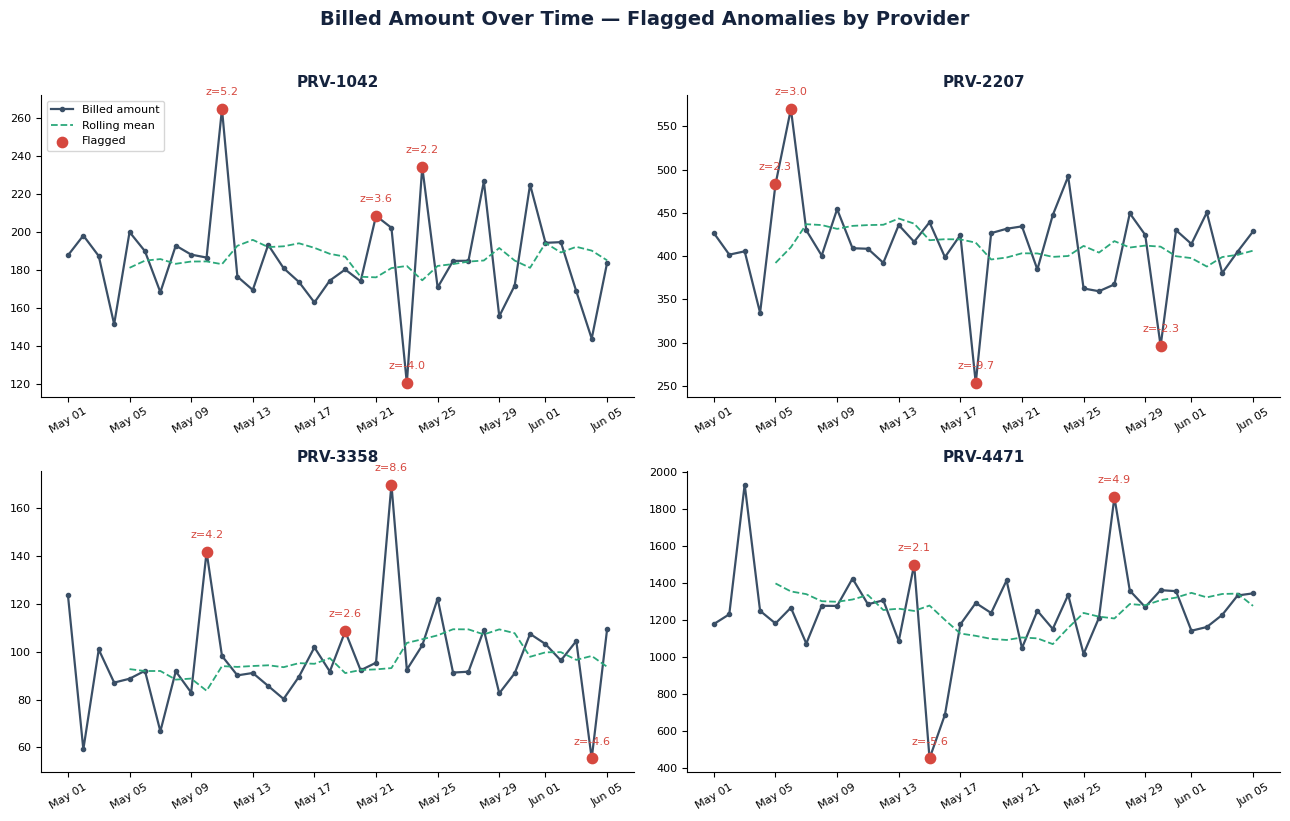

In [5]:
def plot_provider(df, provider_id, ax):
    sub = df[df["provider_id"] == provider_id].sort_values("date")
    ax.plot(sub["date"], sub["billed_amount"], color="#3A4F66", linewidth=1.6,
            marker="o", markersize=3, label="Billed amount")
    ax.plot(sub["date"], sub["rolling_mean"], color="#2BA87B", linewidth=1.3,
            linestyle="--", label="Rolling mean")

    flagged_sub = sub[sub["flagged"]]
    ax.scatter(flagged_sub["date"], flagged_sub["billed_amount"],
               color="#D6483F", s=55, zorder=5, label="Flagged")

    for _, row in flagged_sub.iterrows():
        ax.annotate(f"z={row.z_score:.1f}", (row["date"], row["billed_amount"]),
                    textcoords="offset points", xytext=(0, 10),
                    fontsize=8, color="#D6483F", ha="center")

    ax.set_title(provider_id, fontsize=11, fontweight="bold", color="#15233D")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)


fig, axes = plt.subplots(2, 2, figsize=(13, 8))
provider_ids = claims["provider_id"].unique()
for ax, pid in zip(axes.flat, provider_ids):
    plot_provider(claims, pid, ax)

axes.flat[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Billed Amount Over Time — Flagged Anomalies by Provider",
             fontsize=14, fontweight="bold", color="#15233D", y=1.02)
plt.tight_layout()
plt.savefig("anomaly_detection_results.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Summary by provider

A quick rollup of flag rates per provider — the kind of table that would
feed a payment-integrity investigator's queue in a real system.

In [6]:
summary = (
    claims.groupby("provider_id")
    .agg(
        claims_analyzed=("billed_amount", "count"),
        flagged=("flagged", "sum"),
        max_abs_z=("z_score", lambda s: s.abs().max()),
    )
)
summary["flag_rate"] = (summary["flagged"] / summary["claims_analyzed"]).map(lambda x: f"{x:.1%}")
summary


,claims_analyzed,flagged,max_abs_z,flag_rate
provider_id,,,,
PRV-1042,36,4,5.24,11.1%
PRV-2207,36,4,9.68,11.1%
PRV-3358,36,4,8.63,11.1%
PRV-4471,36,3,5.64,8.3%


## 7. Sensitivity comparison

Sweeping the z-score threshold shows the classic precision/recall tradeoff
that any real fraud, waste, and abuse model has to navigate: a lower
threshold catches more true anomalies but also raises the flag rate (and
investigator workload) overall.

In [7]:
thresholds = [1.5, 2.0, 2.5, 3.0, 3.5]
rows = []
for t in thresholds:
    flag_count = (claims["z_score"].abs() >= t).sum()
    rows.append({"z_threshold": t, "flagged_claims": int(flag_count),
                 "flag_rate": f"{flag_count / len(claims):.1%}"})

pd.DataFrame(rows)


,z_threshold,flagged_claims,flag_rate
0,1.50,20,13.9%
1,2.00,15,10.4%
2,2.50,11,7.6%
3,3.00,9,6.2%
4,3.50,9,6.2%


## 8. Architecture bridge: handing off to Node 2

In this reference pipeline, any claim crossing the sensitivity threshold
(by default, |z| ≥ 2.0) is treated as a trigger event and its record is
handed off to **Node 2: the Agentic Claims Investigator**
(`Agentic_Claims_Investigator.ipynb`). Node 2 takes the statistical flag
produced here — provider, date, billed amount, rolling mean, z-score — and
runs it through a real multi-step LLM reasoning chain that gathers
supporting evidence (claim history, policy language) and produces a
structured, auditable recommendation for a human investigator.

The cell below extracts exactly the payload Node 2 expects, in the same
shape used throughout that notebook.

In [8]:
# Build the Node-1-to-Node-2 handoff payload: every flagged claim, in the
# field shape Node 2 (Agentic_Claims_Investigator.ipynb) expects.
handoff_payload = flagged[
    ["provider_id", "date", "billed_amount", "rolling_mean", "z_score", "reason_code"]
].copy()
handoff_payload["date"] = handoff_payload["date"].dt.strftime("%Y-%m-%d")
handoff_payload["rolling_mean"] = handoff_payload["rolling_mean"].round(2)
handoff_payload["z_score"] = handoff_payload["z_score"].round(2)
handoff_records = handoff_payload.to_dict(orient="records")

print(f"{len(handoff_records)} flagged claims ready for Node 2 hand-off:\n")
for r in handoff_records[:3]:
    print(r)
print("..." if len(handoff_records) > 3 else "")


15 flagged claims ready for Node 2 hand-off:

{'provider_id': 'PRV-1042', 'date': '2026-05-11', 'billed_amount': 264.76, 'rolling_mean': 182.98, 'z_score': 5.24, 'reason_code': '5.2σ above the trailing mean ($183)'}
{'provider_id': 'PRV-1042', 'date': '2026-05-21', 'billed_amount': 208.47, 'rolling_mean': 176.03, 'z_score': 3.6, 'reason_code': '3.6σ above the trailing mean ($176)'}
{'provider_id': 'PRV-1042', 'date': '2026-05-23', 'billed_amount': 120.35, 'rolling_mean': 182.04, 'z_score': -3.99, 'reason_code': '4.0σ below the trailing mean ($182)'}
...


## 9. Conclusion

This notebook implements Node 1 of the Cotiviti Agentic Audit Copilot: a
transparent, pandas-based trigger engine that reproduces the same rolling
z-score anomaly detection used in the interactive HTML proof of concept.
On its own, it answers "is this claim statistically unusual?" — exactly the
trigger condition the written report describes for surfacing pre-pay DRG
upcoding and other aberrant utilization behavior before it consumes analyst
time. It deliberately stops there: Node 1 does not narrate, investigate, or
recommend. That reasoning step belongs to Node 2, which takes the
`handoff_records` produced above and runs the evidence-gathering, chain
reasoning, and structured recommendation that turn a statistical flag into
an analyst-ready audit file.